# Random Variance in Mutation

In [4]:
# dictionaries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.stats import truncnorm, lognorm, gamma


### Haploid

#### One Allele Modifier

In [2]:
def simulate_haploid_selection_mutation(x1, u1, v1, s, generations):
    """
    Simulates haploid population dynamics under selection and mutation.

    Args:
        x1 (float): Initial frequency of AM1 (allele A).
        u1 (float): Mutation rate from A to a.
        v1 (float): Mutation rate from a to A.
        s (float): Selection coefficient against a.
        generations (int): Number of generations to simulate.

    Returns:
        list of float: History of x1 (frequency of AM1) over generations.
    """
    # Initialize history with full precision
    history = [float(x1)]

    for _ in range(generations):
        # Calculate x2 as 1 - x1 with full precision
        x2 = 1.0 - x1

        # Compute fitnesses with full precision
        W_A = 1.0
        W_a = 1.0 - float(s)
        
        W_bar = W_A * x1 + W_a * x2

        # Selection step
        x1_prime = float(x1) * W_A / W_bar
        x2_prime = float(x2) * W_a / W_bar

        # Mutation step with full precision
        x1_next = float(x1_prime) * (1.0 - float(u1)) + float(x2_prime) * float(v1)
        x2_next = float(x2_prime) * (1.0 - float(v1)) + float(x1_prime) * float(u1)

        # Normalize frequencies to ensure they sum to 1
        total = x1_next + x2_next
        x1_next /= total
        x2_next /= total

        # Update for next generation
        x1 = float(x1_next)
        history.append(x1)
        
    return history

### Figure 1

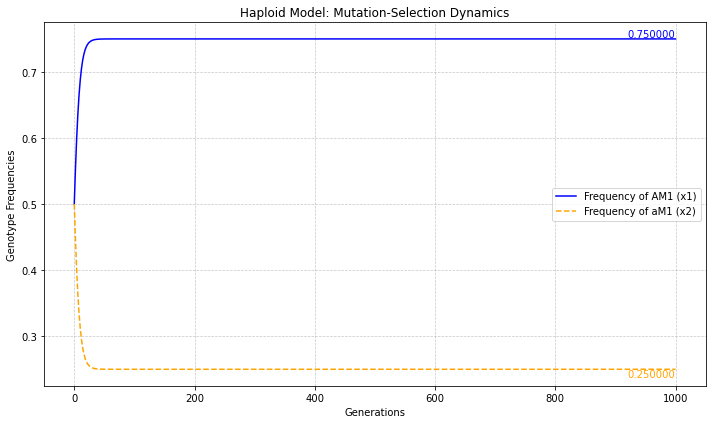

In [3]:
# Parameters
x1_initial = 0.5  # Initial frequency of AM1
u1 = 0.05  # Mutation rate from A to a
v1 = 0.  # Mutation rate from a to A
s = 0.2  # Selection coefficient against a
generations = 1000  # Number of generations to simulate

# Run the simulation
x1_history = simulate_haploid_selection_mutation(x1_initial, u1, v1, s, generations)

# Determine the convergent values
convergent_value_AM1 = x1_history[-1]  # Final value of AM1
convergent_value_aM1 = 1 - convergent_value_AM1  # Final value of aM1

plt.figure(figsize=(10, 6))
plt.plot(x1_history, label="Frequency of AM1 (x1)", color='blue')
plt.plot([1 - x for x in x1_history], label="Frequency of aM1 (x2)", linestyle='--', color='orange')

# Add labels for the convergent values with more decimal places
plt.text(len(x1_history) - 1, convergent_value_AM1, f'{convergent_value_AM1:.6f}', 
         verticalalignment='bottom', horizontalalignment='right', color='blue')
plt.text(len(x1_history) - 1, convergent_value_aM1, f'{convergent_value_aM1:.6f}', 
         verticalalignment='top', horizontalalignment='right', color='orange')

plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.xlabel("Generations")
plt.ylabel("Genotype Frequencies")
plt.title("Haploid Model: Mutation-Selection Dynamics")
plt.legend()
plt.tight_layout() 
plt.show()

#### Two Allele Modifier

In [4]:
def haploid_mutation_2m(generations, s, u1, u2, v1, v2, x1_init, x2_init, x3_init, x4_init, sigma_2=0.0):
    """
    Simulate the genetic model with given parameters.

    Parameters:
    generations : int - Number of generations to simulate
    s : float - Selection coefficient
    u1, u2 : float - Forward mutation rates
    v1, v2 : float - Back mutation rates
    sigma_2 : float - Standard deviation for stochastic u2
    x1_init, x2_init, x3_init, x4_init : float - Initial frequencies of genotypes AM1, aM1, AM2, aM2

    Returns:
    Frequencies of x1, x2, x3, x4 over generations and a plot of their trajectories.
    """
    # Fitness values
    W_A = 1 
    W_a = 1 - s

    # Arrays to store frequencies over generations
    x1 = np.zeros(generations)
    x2 = np.zeros(generations)
    x3 = np.zeros(generations)
    x4 = np.zeros(generations)

    # Initialize frequencies
    x1[0], x2[0], x3[0], x4[0] = x1_init, x2_init, x3_init, x4_init

    # Function to calculate mean fitness
    def mean_fitness(x1, x2, x3, x4, W_A, W_a):
        return x1 * W_A + x2 * W_a + x3 * W_A + x4 * W_a

    # Evolution over generations
    for t in range(1, generations):
        # Sample stochastic u2 from a normal distribution
        u2_t = u2 + np.random.normal(0, sigma_2)
        # Resample until u2_t is within [0, 1]
        while u2_t < 0.0 or u2_t > 1.0:
            u2_t = u2 + np.random.normal(0, sigma_2)
        
        # # Sample stochastic u2 from a log-normal distribution
        # sigma = np.sqrt(np.log(1 + (sigma_2 / u2)**2))
        # mu = np.log(u2) - 0.5 * sigma**2
        # u2_t = np.random.lognormal(mean=mu, sigma=sigma)

        # Calculate mean fitness
        W_mean = mean_fitness(x1[t-1], x2[t-1], x3[t-1], x4[t-1], W_A, W_a)

        # After selection
        x1_prime = x1[t-1] * W_A / W_mean
        x2_prime = x2[t-1] * W_a / W_mean
        x3_prime = x3[t-1] * W_A / W_mean
        x4_prime = x4[t-1] * W_a / W_mean

        # After mutation
        x1[t] = x1_prime * (1 - u1) + x2_prime * v1
        x2[t] = x2_prime * (1 - v1) + x1_prime * u1
        x3[t] = x3_prime * (1 - u2_t) + x4_prime * v2
        x4[t] = x4_prime * (1 - v2) + x3_prime * u2_t

        total = x1[t] + x2[t] + x3[t] + x4[t]
        x1[t] /= total
        x2[t] /= total
        x3[t] /= total
        x4[t] /= total


    return x1, x2, x3, x4


0.7499999999999997 0.25000000000000033 0.0 0.0


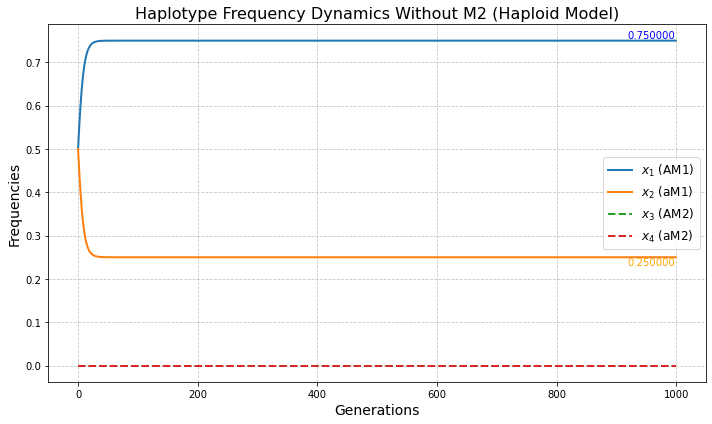

In [5]:
# Just checking it works as predicted
# Define the parameters for the simulation where M2 is not introduced yet
generations = 1000
s = 0.2  # Selection coefficient
u1 = 0.05  # Forward mutation rate for M1
u2 = 0.0  # Forward mutation rate for M2 (not introduced yet)
v1 = 0.0  # Back mutation rate for M1
v2 = 0.0  # Back mutation rate for M2
x1_init = 0.5  # Initial frequency of AM1
x2_init = 0.5  # Initial frequency of aM1
x3_init = 0.0  # Initial frequency of AM2 (not introduced)
x4_init = 0.0  # Initial frequency of aM2 (not introduced)
sigma_2 = 0.0  # No stochasticity in u2

# Simulate the model
x1, x2, x3, x4 = haploid_mutation_2m(
    generations=generations,
    s=s,
    u1=u1,
    u2=u2,
    v1=v1,
    v2=v2,
    x1_init=x1_init,
    x2_init=x2_init,
    x3_init=x3_init,
    x4_init=x4_init,
    sigma_2=sigma_2
)
print(x1[-1], x2[-1], x3[-1], x4[-1])

# Plot the frequencies over generations
plt.figure(figsize=(10, 6))
plt.plot(np.arange(generations), x1, label=r'$x_1$ (AM1)', linewidth=2)
plt.plot(np.arange(generations), x2, label=r'$x_2$ (aM1)', linewidth=2)
plt.plot(np.arange(generations), x3, label=r'$x_3$ (AM2)', linewidth=2, linestyle='--')
plt.plot(np.arange(generations), x4, label=r'$x_4$ (aM2)', linewidth=2, linestyle='--')

# Add labels for the convergent values with more decimal places
plt.text(len(x1) - 1, x1[-1], f'{x1[-1]:.6f}', 
         verticalalignment='bottom', horizontalalignment='right', color='blue')
plt.text(len(x1) - 1, x2[-1], f'{x2[-1]:.6f}', 
         verticalalignment='top', horizontalalignment='right', color='orange')

# Adding labels and legend
plt.xlabel('Generations', fontsize=14)
plt.ylabel('Frequencies', fontsize=14)
plt.title('Haplotype Frequency Dynamics Without M2 (Haploid Model)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


### Figure 2

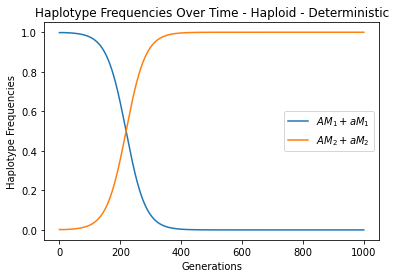

In [29]:
# Deterministic
t= 0.001
x1, x2, x3, x4 = haploid_mutation_2m(
    generations=1000,
    s=0.2,
    u1=0.05,
    u2=0.02,
    v1=0,
    v2=0,
    x1_init= .75-t,
    x2_init= .25-t,
    x3_init= t,
    x4_init= t
)

# Plot results
plt.plot(x1+x2, label="$AM_1 + aM_1$")
plt.plot(x3+x4, label="$AM_2 + aM_2$")
plt.xlabel("Generations")
plt.ylabel("Haplotype Frequencies")
plt.title("Haplotype Frequencies Over Time - Haploid - Deterministic")
plt.legend()
plt.show()

In [7]:
def plot_grouped_frequencies(x1, x2, x3, x4):
    """
    Plot the grouped frequencies for M1 (AM1 + aM1) and M2 (AM2 + aM2) based on the original haplotype frequencies.

    Parameters:
    x1, x2, x3, x4 : numpy arrays - Frequencies of AM1, aM1, AM2, and aM2 over generations.
    """
    # Calculate grouped frequencies
    M1 = x1 + x2  # M1 = AM1 + aM1
    M2 = x3 + x4  # M2 = AM2 + aM2

    # Plot grouped results
    plt.plot(M1, label="M1 (AM1 + aM1)")
    plt.plot(M2, label="M2 (AM2 + aM2)")
    plt.xlabel("Generations")
    plt.ylabel("Frequencies")
    plt.title("Grouped Genotype Frequencies Over Time")
    plt.legend()
    plt.show()

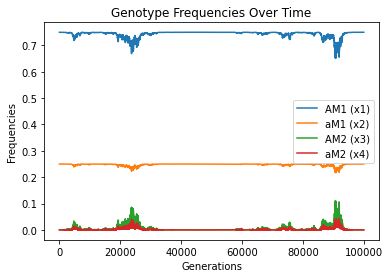

In [8]:
# Stochastic 
t=0.0001
x1, x2, x3, x4 = haploid_mutation_2m(
    generations=100000,
    s=0.2,
    u1=0.05,
    u2=0.02,
    v1=0,
    v2=0,
    x1_init= .75-t,
    x2_init= .25-t,
    x3_init= t,
    x4_init= t,
    sigma_2 = 0.0515
)
 # Plot results
plt.plot(x1, label="AM1 (x1)")
plt.plot(x2, label="aM1 (x2)")
plt.plot(x3, label="AM2 (x3)")
plt.plot(x4, label="aM2 (x4)")
plt.xlabel("Generations")
plt.ylabel("Frequencies")
plt.title("Genotype Frequencies Over Time")
plt.legend()
plt.show()

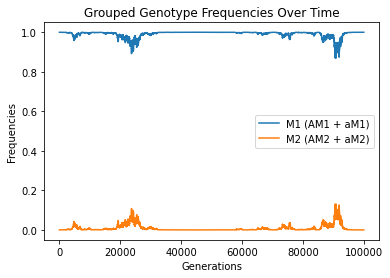

In [9]:
plot_grouped_frequencies(x1, x2, x3, x4)

In [10]:
def plot_final_frequencies_with_sigma(
    sigma_values, generations, s, u1, u2, v1, v2, x1_init, x2_init, x3_init, x4_init
):
    """
    Run haploid_mutation_2m for n steps with a range of sigma_2 values
    and plot final frequencies of M1 and M2.

    Parameters:
    sigma_values : numpy array - Range of sigma_2 values to test
    generations : int - Number of generations to simulate
    s : float - Selection coefficient
    u1, u2 : float - Forward mutation rates
    v1, v2 : float - Back mutation rates
    x1_init, x2_init, x3_init, x4_init : float - Initial frequencies of genotypes AM1, aM1, AM2, aM2

    Returns:
    None (plots the results directly).
    """
    final_M1 = []
    final_M2 = []

    for sigma_2 in sigma_values:
        # Run haploid_mutation_2m for the given sigma_2
        x1, x2, x3, x4 = haploid_mutation_2m(
            generations=generations,
            s=s,
            u1=u1,
            u2=u2,
            v1=v1,
            v2=v2,
            x1_init=x1_init,
            x2_init=x2_init,
            x3_init=x3_init,
            x4_init=x4_init,
            sigma_2=sigma_2,
        )

        # Compute final grouped frequencies
        M1_final = x1[-1] + x2[-1]
        M2_final = x3[-1] + x4[-1]

        final_M1.append(M1_final)
        final_M2.append(M2_final)

    # Plot results
    plt.plot(sigma_values, final_M1, label="M1 (AM1 + aM1)")
    plt.plot(sigma_values, final_M2, label="M2 (AM2 + aM2)")
    plt.xlabel(r"$\sigma_2$")
    plt.ylabel("Frequencies after 100000 Steps")
    plt.title("Final Frequencies vs. $\sigma_2$")
    plt.legend()
    plt.show()



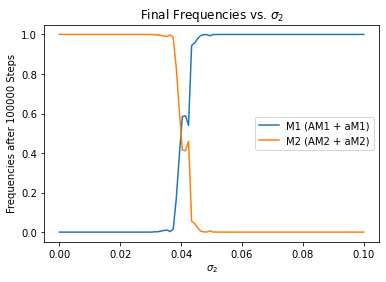

In [12]:
sigma_values = np.linspace(0, 0.1, 100)
plot_final_frequencies_with_sigma(
    sigma_values=sigma_values,
    generations=1000,
    s=0.2,
    u1=0.05,
    u2=0.02,
    v1=0,
    v2=0,
    x1_init= .75-t,
    x2_init= .25-t,
    x3_init= t,
    x4_init= t
)

### Figure 3

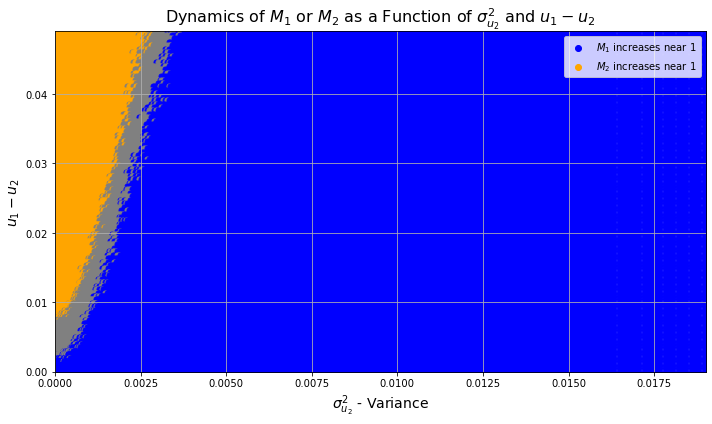

In [27]:
# Parameters
generations = 1000
u1 = 0.05
u2_values = np.linspace(0.001, 0.05, 100)
sigma_u_values = np.linspace(0, 0.14, 300)
s, v1, v2, dot_size = 0.2, 0.0, 0.0, 25

 # Generate random t1 and t2 ensuring sum is 1
t1, t2 = np.random.uniform(0, 0.01, 2)
total_t = t1 + t2
x1_init = 0.75 - total_t / 2
x2_init = 0.25 - total_t / 2
x3_init = t1
x4_init = t2

# Plot setup
plt.figure(figsize=(10, 6))

for u2 in u2_values:
    for sigma_2 in sigma_u_values:
        x1, x2, x3, x4 = haploid_mutation_2m(generations, s, u1, u2, v1, v2, x1_init, x2_init, x3_init, x4_init, sigma_2)
        M1_final, M2_final = x1[-1] + x2[-1], x3[-1] + x4[-1]
        
        color = 'blue' if M1_final > 0.95 else 'orange' if M2_final > 0.95 else 'gray'
        plt.scatter(sigma_2**2, u1 - u2, color=color, s=dot_size)

plt.xlabel(r'$\sigma_{u_2}^2$ - Variance', fontsize=14)
plt.ylabel(r'$u_1 - u_2$', fontsize=14)
plt.title('Dynamics of $M_1$ or $M_2$ as a Function of $\sigma_{u_2}^2$ and $u_1 - u_2$', fontsize=16)
plt.scatter([], [], color='blue', label=r'$M_1$ increases near 1')
plt.scatter([], [], color='orange', label=r'$M_2$ increases near 1')
plt.legend()
plt.grid(True)
plt.xlim(0,0.019)
plt.ylim(0, 0.049)  
plt.tight_layout()
plt.show()


## Different Distributions

### Figure 4

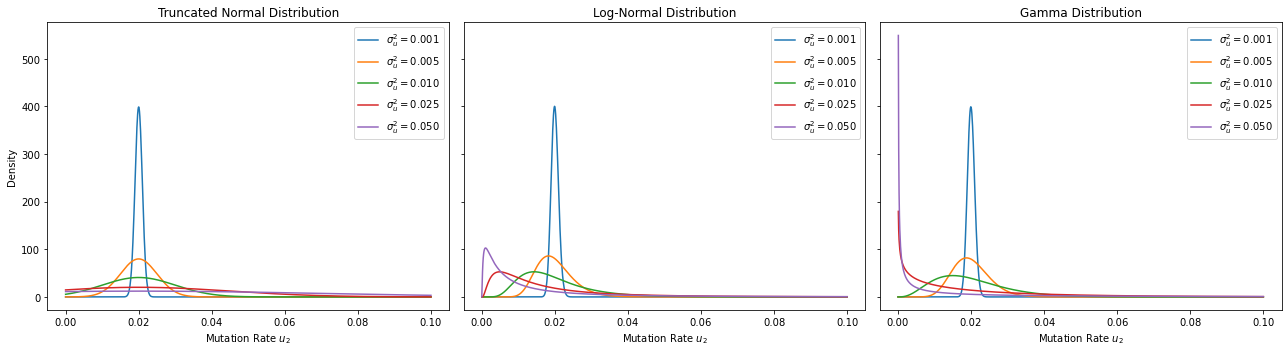

In [57]:
# Set fixed u2 value
u2_fixed = 0.02  

# Define sigma_u values for visualization
sigma_u_values = [0.001, 0.005, 0.01, 0.025, 0.05]  # Example values for different spread

# Define range for plotting distributions
x_values = np.linspace(0, 0.1, 1000)

# Setting up the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=True)

# 1. Truncated Normal Distribution
for sigma_u in sigma_u_values:
    a, b = (0 - u2_fixed) / sigma_u, (1 - u2_fixed) / sigma_u  # Truncation bounds
    y_truncnorm = truncnorm.pdf(x_values, a, b, loc=u2_fixed, scale=sigma_u)
    axes[0].plot(x_values, y_truncnorm, label=f"$\sigma^2_u={sigma_u:.3f}$")

axes[0].set_title("Truncated Normal Distribution")
axes[0].set_xlabel("Mutation Rate $u_2$")
axes[0].set_ylabel("Density")
axes[0].legend()

# 2. Log-Normal Distribution
for sigma_u in sigma_u_values:
    sigma = np.sqrt(np.log(1 + (sigma_u / u2_fixed) ** 2))
    mu = np.log(u2_fixed) - 0.5 * sigma**2
    y_lognorm = lognorm.pdf(x_values, sigma, scale=np.exp(mu))
    axes[1].plot(x_values, y_lognorm, label=f"$\sigma^2_u={sigma_u:.3f}$")

axes[1].set_title("Log-Normal Distribution")
axes[1].set_xlabel("Mutation Rate $u_2$")
axes[1].legend()

# 3. Gamma Distribution
for sigma_u in sigma_u_values:
    shape = (u2_fixed / sigma_u) ** 2
    scale = sigma_u ** 2 / u2_fixed
    y_gamma = gamma.pdf(x_values, shape, scale=scale)
    axes[2].plot(x_values, y_gamma, label=f"$\sigma^2_u={sigma_u:.3f}$")

axes[2].set_title("Gamma Distribution")
axes[2].set_xlabel("Mutation Rate $u_2$")
axes[2].legend()

plt.tight_layout()
plt.show()


### Figure 5

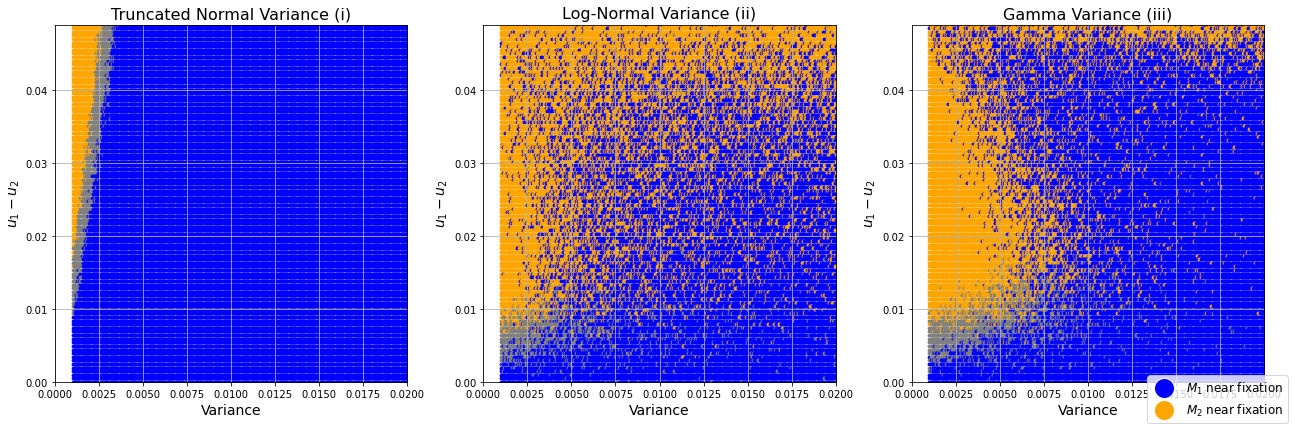

In [62]:

# Function to simulate stochastic mutation with different stochasticity models
def simulate_stochastic_mutation(sigma_u, variance, u2_mean, initial_frequencies, timesteps=1000, u1=0.05, s=0.2, v1=0.0, distribution="truncated_normal", seed=None):
    """
    Simulates the evolution of haplotype frequencies under different stochastic mutation rate models.
    """
    if not np.isclose(sum(initial_frequencies), 1.0):
        raise ValueError("Initial frequencies must sum to 1.")

    rng = np.random.default_rng(seed)

    # Unpack initial frequencies
    x1, x2, x3, x4 = map(float, initial_frequencies)
    frequencies = np.zeros((timesteps, 4))

    for t in range(timesteps):
        frequencies[t] = [x1, x2, x3, x4]

        # Stochastic mutation rate for M2
        while True:
            if distribution == "truncated_normal":
                sigma_u = np.sqrt(variance)
                a, b = (0 - u2_mean) / sigma_u, (1 - u2_mean) / sigma_u
                u2_stochastic = truncnorm.rvs(a, b, loc=u2_mean, scale=sigma_u, random_state=rng)

            elif distribution == "log_normal":
                sigma = np.sqrt(np.log(1 + variance / u2_mean**2))
                mu = np.log(u2_mean) - 0.5 * sigma**2
                u2_stochastic = rng.lognormal(mean=mu, sigma=sigma)
                u2_stochastic = np.clip(u2_stochastic, 0, 1)

            elif distribution == "gamma":
                shape = u2_mean**2 / variance
                scale = variance / u2_mean
                u2_stochastic = rng.gamma(shape, scale)
                u2_stochastic = np.clip(u2_stochastic, 0, 1)

            if 0 <= u2_stochastic <= 1:
                break

        W_A = 1 
        W_a = 1 - s
        # Mean fitness
        w_bar = (x1 * W_A + x2 * W_a + x3 * W_A + x4 * W_a)

        # Selection step
        x1_prime = x1 * W_A/ w_bar
        x2_prime = x2 * W_a/ w_bar
        x3_prime = x3 * W_A/ w_bar
        x4_prime = x4 * W_a/ w_bar

        # Mutation step
        x1 = x1_prime * (1 - u1) + x2_prime * v1
        x2 = x2_prime * (1 - v1) + x1_prime * u1
        x3 = x3_prime * (1 - u2_stochastic) + x4_prime * v1
        x4 = x4_prime * (1 - v1) + x3_prime * u2_stochastic

        # Normalize frequencies
        total = x1 + x2 + x3 + x4
        x1, x2, x3, x4 = x1 / total, x2 / total, x3 / total, x4 / total

    return np.round(frequencies, 6), variance

# Parameters for simulation

generations = 1000
u1 = 0.05
s, v1, v2, dot_size = 0.2, 0.0, 0.0, 25

 # Generate random t1 and t2 ensuring sum is 1
t1, t2 = np.random.uniform(0, 0.01, 2)
total_t = t1 + t2
x1_init = 0.75 - total_t / 2
x2_init = 0.25 - total_t / 2
x3_init = t1
x4_init = t2

# Parameter ranges
u2_mean_values = np.linspace(0.001, u1, 100)  # Mean u2 from 0.001 to u1
variance_values = np.linspace(0.001, 0.02, 300)  # Focused variance range for better resolution

distributions = ["truncated_normal", "log_normal", "gamma"]
titles = ["Truncated Normal Variance (i)", "Log-Normal Variance (ii)", "Gamma Variance (iii)"]

# Generate plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, distribution in enumerate(distributions):
    ax = axes[idx]
    
    for u2_mean in u2_mean_values:
        for variance in variance_values:
            sigma_u = np.sqrt(variance) if distribution == "truncated_normal" else None

            # Simulate the model
            freqs, actual_variance = simulate_stochastic_mutation(
                sigma_u=sigma_u,
                variance=variance,
                u2_mean=u2_mean,
                initial_frequencies=[x1_init, x2_init, x3_init, x4_init],
                timesteps=generations,
                u1=u1,
                s=s,
                v1=v1,
                distribution=distribution,
            )

            # Compute final frequencies
            M1_final = freqs[-1, 0] + freqs[-1, 1]  # AM1 + aM1
            M2_final = freqs[-1, 2] + freqs[-1, 3]  # AM2 + aM2

            # Determine color
            if M1_final > 0.95:
                color = "blue"
            elif M2_final > 0.95:
                color = "orange"
            else:
                color = "gray"

            # Scatter plot
            ax.scatter(actual_variance, u1 - u2_mean, color=color, s=8)

    # Labels and formatting
    ax.set_xlabel("Variance", fontsize=14)
    ax.set_ylabel(r"$u_1 - u_2$", fontsize=14)
    ax.set_title(titles[idx], fontsize=16)
    ax.grid(True)
    ax.set_ylim(0, 0.049)
    ax.set_xlim(0, 0.02)  # Zoom in on variance axis

# Legend
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markersize=20, markerfacecolor="blue", label=r"$M_1$ near fixation"),
    plt.Line2D([0], [0], marker="o", color="w", markersize=20, markerfacecolor="orange", label=r"$M_2$ near fixation"),
]
fig.legend(handles=handles, loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()


## Diploid

In [67]:
import numpy as np

def simulate_stochastic_mutation(sigma_u, initial_frequencies, timesteps=1000, 
                                 u1=0.01, u2=0.02, u3=0.03, 
                                 s=0.2, R=0.1, seed=None):
    """
    Simulates diploid evolution with genotype-dependent mutation rates at A/a,
    modified by M1/M2 background. Only A → a mutation occurs (no back mutation).

    Haplotypes:
    - x1: AM1
    - x2: AM2
    - x3: aM1
    - x4: aM2

    Parameters:
    - sigma_u (float): Std dev of stochastic fluctuation on u2 (M1M2 genotype).
    - initial_frequencies (list): Initial haplotype frequencies [x1, x2, x3, x4].
    - timesteps (int): Number of generations to simulate.
    - u1, u2, u3 (float): A→a mutation rates for M1M1, M1M2, M2M2.
    - s (float): Selection coefficient (heterozygote fitness = 1 - s).
    - R (float): Recombination rate between A/a and M1/M2 loci.
    - seed (int or None): RNG seed for reproducibility.

    Returns:
    - np.ndarray: Trajectory of haplotype frequencies over time (timesteps × 4).
    """
    if not np.isclose(sum(initial_frequencies), 1.0):
        raise ValueError("Initial frequencies must sum to 1.")
    
    rng = np.random.default_rng(seed)
    x1, x2, x3, x4 = map(float, initial_frequencies)
    freq_traj = np.zeros((timesteps, 4))

    w11 = 1.0
    w12 = 1.0 - s
    w22 = 1.0 - 2 * s

    for t in range(timesteps):
        freq_traj[t] = [x1, x2, x3, x4]

        # Stochastic mutation rate for M1M2
        while True:
            u2_stochastic = u2 + rng.normal(0, sigma_u)
            if 0 <= u2_stochastic <= 1:
                break

        # Mean fitness
        w_bar = (
            (x1 + x2)**2 * w11 +
            2 * w12 * (x1 + x2) * (x3 + x4) +
            (x3 + x4)**2 * w22
        )

        # Selection and mutation dynamics
        x1_new = (1 - u1) * (x1**2 * w11 + x1 * x3 * w12) + \
                 (1 - u2_stochastic) * (x1 * x2 * w11 + x1 * x4 * w12 - w12 * R * (x1 * x4 - x2 * x3))
        
        x2_new = (1 - u3) * (x2**2 * w11 + x2 * x4 * w12) + \
                 (1 - u2_stochastic) * (x1 * x2 * w11 + x2 * x3 * w12) + \
                 w12 * R * (x1 * x4 - x2 * x3)
        
        x3_new = x3**2 * w22 + x1 * x3 * w12 + x2 * x3 * w12 + x3 * x4 * w22 + \
                 w12 * R * (x1 * x4 - x2 * x3) + \
                 u1 * (x1**2 * w11 + x1 * x3 * w12) + \
                 u2_stochastic * (x1 * x2 * w11 + x1 * x4 * w12 - w12 * R * (x1 * x4 - x2 * x3))
        
        x4_new = x4**2 * w22 + x1 * x4 * w12 + x2 * x4 * w12 + x3 * x4 * w22 - \
                 w12 * R * (x1 * x4 - x2 * x3) + \
                 u3 * (x2**2 * w11 + x2 * x4 * w12) + \
                 u2_stochastic * (x1 * x2 * w11 + x2 * x3 * w12 + w12 * R * (x1 * x4 - x2 * x3))

        # Normalize
        total = x1_new + x2_new + x3_new + x4_new
        x1, x2, x3, x4 = x1_new / total, x2_new / total, x3_new / total, x4_new / total

    return np.round(freq_traj, 6)


### Figure 6

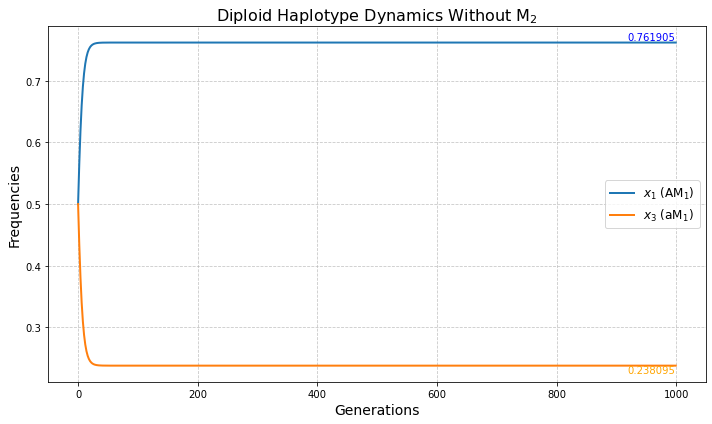

In [69]:
# Initial condition: only M1 alleles
# t1, t2 = np.random.uniform(0, 0.01, 2)
# total_t = t1 + t2
# initial_frequencies_no_M2 = [0.5 - total_t / 2, t1, 0.5 - total_t / 2, t2]

initial_frequencies_no_M2 = [0.5, 0, 0.5, 0]
timesteps = 1000

frequencies_no_M2 = simulate_stochastic_mutation(
    sigma_u=0.0,  # No stochasticity, M2 not present
    initial_frequencies=initial_frequencies_no_M2,
    timesteps=timesteps,
    u1=0.05, u2=0.02, u3=0.01,
    s=0.2, R=0.1, seed=58
)

plt.figure(figsize=(10, 6))
generations = np.arange(timesteps)
plt.plot(generations, frequencies_no_M2[:, 0], label=r'$x_1$ (AM$_1$)', linewidth=2)
plt.plot(generations, frequencies_no_M2[:, 2], label=r'$x_3$ (aM$_1$)', linewidth=2)

plt.text(timesteps - 1, frequencies_no_M2[-1, 0], f'{frequencies_no_M2[-1, 0]:.6f}', 
         va='bottom', ha='right', color='blue')
plt.text(timesteps - 1, frequencies_no_M2[-1, 2], f'{frequencies_no_M2[-1, 2]:.6f}', 
         va='top', ha='right', color='orange')

plt.xlabel("Generations", fontsize=14)
plt.ylabel("Frequencies", fontsize=14)
plt.title("Diploid Haplotype Dynamics Without M$_2$", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


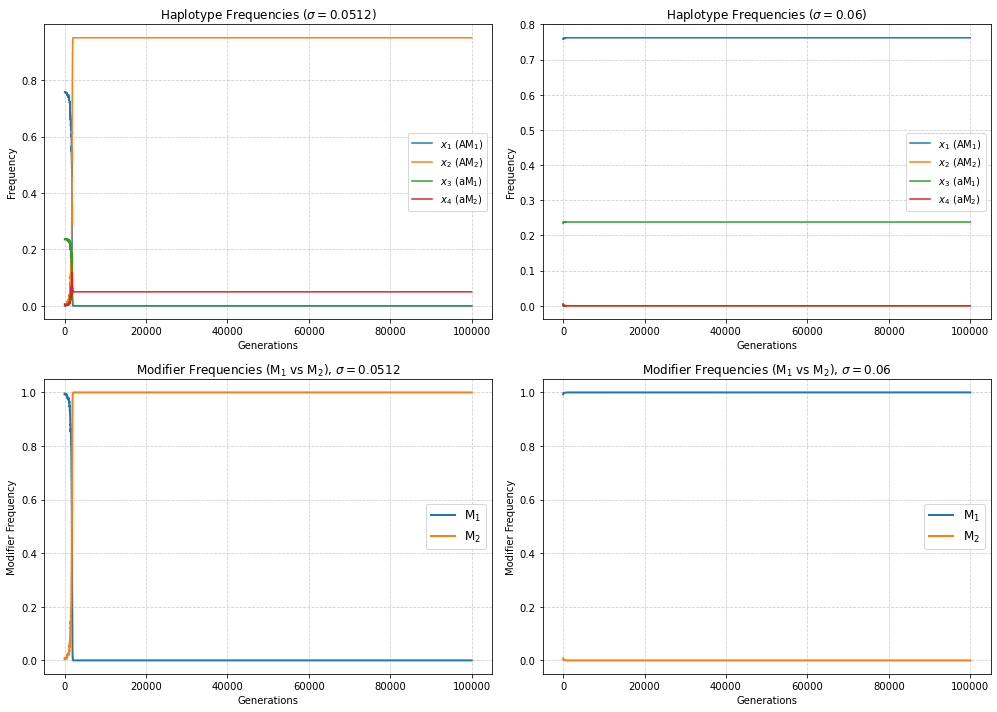

In [70]:
# Small M2 introduction
t1, t2 = np.random.uniform(0, 0.01, 2)
total_t = t1 + t2
initial_frequencies = [0.761905 - total_t / 2, t1, 0.238095 - total_t / 2, t2]
timesteps = 100000

frequencies_sigma_0 = simulate_stochastic_mutation(
    sigma_u=0.0512,
    initial_frequencies=initial_frequencies,
    timesteps=timesteps,
    u1=0.05, u2=0.02, u3=0.01,
    s=0.2, R=0.1, seed=42
)

frequencies_sigma_01 = simulate_stochastic_mutation(
    sigma_u=0.06,
    initial_frequencies=initial_frequencies,
    timesteps=timesteps,
    u1=0.05, u2=0.02, u3=0.01,
    s=0.2, R=0.1, seed=42
)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
labels = [r'$x_1$ (AM$_1$)', r'$x_2$ (AM$_2$)', r'$x_3$ (aM$_1$)', r'$x_4$ (aM$_2$)']
for i, label in enumerate(labels):
    axes[0, 0].plot(frequencies_sigma_0[:, i], label=label)
    axes[0, 1].plot(frequencies_sigma_01[:, i], label=label)

axes[0, 0].set_title(r"Haplotype Frequencies ($\sigma=0.0512$)")
axes[0, 1].set_title(r"Haplotype Frequencies ($\sigma=0.06$)")
for ax in axes[0]:
    ax.set_xlabel("Generations")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.6)

# Modifier frequencies
m1_sigma_0 = frequencies_sigma_0[:, 0] + frequencies_sigma_0[:, 2]
m2_sigma_0 = frequencies_sigma_0[:, 1] + frequencies_sigma_0[:, 3]
m1_sigma_01 = frequencies_sigma_01[:, 0] + frequencies_sigma_01[:, 2]
m2_sigma_01 = frequencies_sigma_01[:, 1] + frequencies_sigma_01[:, 3]

axes[1, 0].plot(m1_sigma_0, label="M$_1$", linewidth=2)
axes[1, 0].plot(m2_sigma_0, label="M$_2$", linewidth=2)
axes[1, 1].plot(m1_sigma_01, label="M$_1$", linewidth=2)
axes[1, 1].plot(m2_sigma_01, label="M$_2$", linewidth=2)

axes[1, 0].set_title(r"Modifier Frequencies (M$_1$ vs M$_2$), $\sigma=0.0512$")
axes[1, 1].set_title(r"Modifier Frequencies (M$_1$ vs M$_2$), $\sigma=0.06$")
for ax in axes[1]:
    ax.set_xlabel("Generations")
    ax.set_ylabel("Modifier Frequency")
    ax.legend(fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


### Figure 7

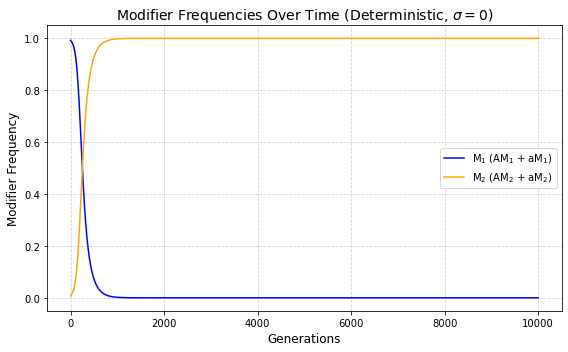

In [74]:
# Initial condition with small perturbation introducing M2
t1, t2 = np.random.uniform(0, 0.01, 2)
total_t = t1 + t2
initial_frequencies = [0.761905 - total_t / 2, t1, 0.238095 - total_t / 2, t2]

# Run deterministic simulation (σ = 0)
frequencies = simulate_stochastic_mutation(
    sigma_u=0.0,
    initial_frequencies=initial_frequencies,
    timesteps=10000,
    u1=0.05, u2=0.02, u3=0.01,
    s=0.2, R=0.1, seed=10
)

# Plot total frequency of M1 and M2 haplotypes over time
plt.figure(figsize=(8, 5))
generations = np.arange(frequencies.shape[0])

plt.plot(generations, frequencies[:, 0] + frequencies[:, 2], label=r'M$_1$ (AM$_1$ + aM$_1$)', color='blue')
plt.plot(generations, frequencies[:, 1] + frequencies[:, 3], label=r'M$_2$ (AM$_2$ + aM$_2$)', color='orange')

plt.title("Modifier Frequencies Over Time (Deterministic, $\sigma=0$)", fontsize=14)
plt.xlabel("Generations", fontsize=12)
plt.ylabel("Modifier Frequency", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [75]:
def plot_final_frequencies(
    sigma_u_values,
    initial_frequencies,
    timesteps=100000,
    u1=0.05,
    u2=0.02,
    u3=0.01,
    s=0.2,
    R=0.1,
    seed=98
):
    """
    Plots final M1 and M2 modifier frequencies as a function of sigma_u
    (standard deviation in the stochastic mutation rate for M1M2 genotypes).

    Parameters:
    - sigma_u_values (array-like): List or array of σ_u values to simulate.
    - initial_frequencies (list of 4 floats): [AM1, AM2, aM1, aM2], must sum to 1.
    - timesteps (int): Number of generations to simulate.
    - u1, u2, u3 (float): Mutation rates A→a for M1M1, M1M2, M2M2 genotypes.
    - s (float): Selection coefficient (w_12 = 1-s, w_22 = 1-2s).
    - R (float): Recombination rate between loci.
    - seed (int): Random seed for reproducibility.

    Returns:
    - None. Displays the plot.
    """

    # Input validation
    if not isinstance(sigma_u_values, (list, np.ndarray)):
        raise TypeError("sigma_u_values must be a list or numpy array.")
    if not np.isclose(sum(initial_frequencies), 1.0):
        raise ValueError("Initial frequencies must sum to 1.")
    
    final_frequencies = np.zeros((len(sigma_u_values), 4))

    for i, sigma_u in enumerate(sigma_u_values):
        freqs = simulate_stochastic_mutation(
            sigma_u=sigma_u,
            initial_frequencies=initial_frequencies,
            timesteps=timesteps,
            u1=u1, u2=u2, u3=u3,
            s=s, R=R,
            seed=seed
        )
        final_frequencies[i] = freqs[-1]

    # Correct grouping based on biological identity
    M1_final = final_frequencies[:, 0] + final_frequencies[:, 2]  # AM1 + aM1
    M2_final = final_frequencies[:, 1] + final_frequencies[:, 3]  # AM2 + aM2

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(sigma_u_values, M1_final, label=r'$M_1$ (AM$_1$ + aM$_1$)', linewidth=2)
    plt.plot(sigma_u_values, M2_final, label=r'$M_2$ (AM$_2$ + aM$_2$)', linewidth=2)

    plt.xlabel(r'$\sigma_u$', fontsize=14)
    plt.ylabel('Final Modifier Frequencies', fontsize=14)
    plt.title(r'Final Frequencies of $M_1$ and $M_2$ vs. $\sigma_u$', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [86]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Fixed parameters
# u1 = 0.05
# u2_values = np.linspace(0.001, 0.05, 100)
# sigma_u_values = np.linspace(0, 0.1, 100)
# s = 0.2
# R = 0.0
# dot_size = 25

# # Generate small random t1 and t2 for M2 perturbation
# t1, t2 = np.random.uniform(0, 0.01, 2)
# total_t = t1 + t2
# x1_init = 0.76 - total_t / 2
# x2_init = t1
# x3_init = 0.24 - total_t / 2
# x4_init = t2

# # Set up the plot
# plt.figure(figsize=(10, 6))

# # Simulate across grid of (u2, sigma_u)
# for u2 in u2_values:
#     for sigma_u in sigma_u_values:
#         frequencies = simulate_stochastic_mutation(
#             sigma_u=sigma_u,
#             initial_frequencies=[x1_init, x2_init, x3_init, x4_init],
#             timesteps=1000,
#             u1=u1,
#             u2=u2,
#             u3=0.01,   # Fixed value for M2M2 mutation rate
#             s=s,
#             R=R,
#             seed=101  # Fixed seed for reproducibility
#         )

#         # Get final frequencies of each haplotype
#         x1, x2, x3, x4 = frequencies[-1]

#         # Compute final M1 and M2 modifier frequencies
#         M1_final = x1 + x3  # AM1 + aM1
#         M2_final = x2 + x4  # AM2 + aM2

#         # Color coding by fixation status
#         if M1_final > 0.95:
#             color = 'blue'    # M1 dominates
#         elif M2_final > 0.95:
#             color = 'orange'  # M2 dominates
#         else:
#             color = 'gray'    # Coexistence or intermediate state

#         # Plot point with x-axis as variance (σ²), y-axis as u₁ - u₂
#         plt.scatter(sigma_u**2, u1 - u2, color=color, s=dot_size)

# # Plot formatting
# plt.xlabel(r'$\sigma_u^2$ (Variance in $u_2$)', fontsize=14)
# plt.ylabel(r'$u_1 - u_2$', fontsize=14)
# plt.title(r'Fixation Outcomes in Diploid Model vs. $\sigma_u^2$ and $u_1 - u_2$', fontsize=16)

# # Custom legend
# plt.scatter([], [], color='blue', label=r'$M_1$ fixation')
# plt.scatter([], [], color='orange', label=r'$M_2$ fixation')
# plt.scatter([], [], color='gray', label='No fixation')
# plt.legend()

# # Limits and grid
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.xlim(0, 0.01)
# plt.ylim(0, 0.049)
# plt.show()


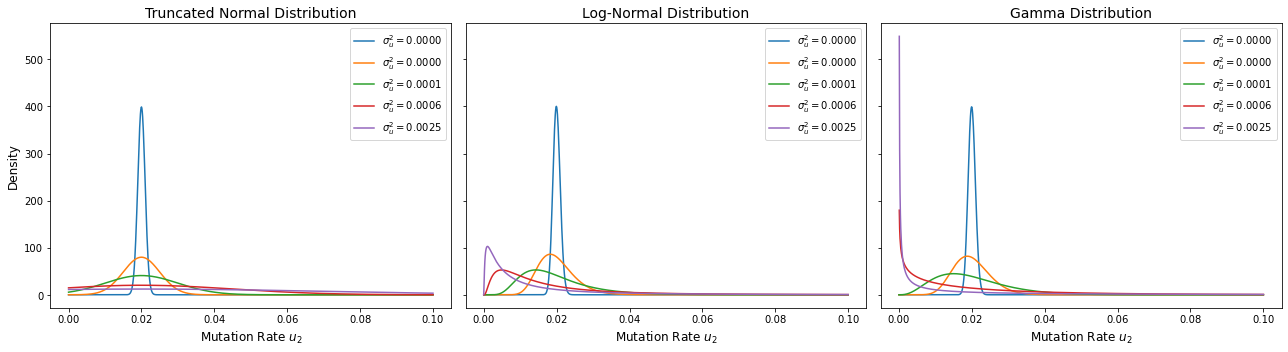

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm, lognorm, gamma

# Fixed mean mutation rate for M1M2 genotype
u2_fixed = 0.02

# Values of standard deviation (σ_u), with labels shown as σ² in plots
sigma_u_values = [0.001, 0.005, 0.01, 0.025, 0.05]

# Range of possible mutation rates to plot
x_values = np.linspace(0, 0.1, 1000)

# Set up 1-row, 3-column figure to compare distribution shapes
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=True)

# --- 1. Truncated Normal Distribution (bounded in [0, 1]) ---
for sigma_u in sigma_u_values:
    a = (0 - u2_fixed) / sigma_u  # lower bound in std units
    b = (1 - u2_fixed) / sigma_u  # upper bound in std units
    y_truncnorm = truncnorm.pdf(x_values, a, b, loc=u2_fixed, scale=sigma_u)
    axes[0].plot(x_values, y_truncnorm, label=fr"$\sigma_u^2 = {sigma_u**2:.4f}$")

axes[0].set_title("Truncated Normal Distribution", fontsize=14)
axes[0].set_xlabel(r"Mutation Rate $u_2$", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].legend(fontsize=10)

# --- 2. Log-Normal Distribution (positive support, right-skewed) ---
for sigma_u in sigma_u_values:
    sigma_ln = np.sqrt(np.log(1 + (sigma_u / u2_fixed) ** 2))
    mu_ln = np.log(u2_fixed) - 0.5 * sigma_ln ** 2
    y_lognorm = lognorm.pdf(x_values, sigma_ln, scale=np.exp(mu_ln))
    axes[1].plot(x_values, y_lognorm, label=fr"$\sigma_u^2 = {sigma_u**2:.4f}$")

axes[1].set_title("Log-Normal Distribution", fontsize=14)
axes[1].set_xlabel(r"Mutation Rate $u_2$", fontsize=12)
axes[1].legend(fontsize=10)

# --- 3. Gamma Distribution (positive support, flexible skewness) ---
for sigma_u in sigma_u_values:
    shape = (u2_fixed / sigma_u) ** 2
    scale = sigma_u ** 2 / u2_fixed
    y_gamma = gamma.pdf(x_values, a=shape, scale=scale)
    axes[2].plot(x_values, y_gamma, label=fr"$\sigma_u^2 = {sigma_u**2:.4f}$")

axes[2].set_title("Gamma Distribution", fontsize=14)
axes[2].set_xlabel(r"Mutation Rate $u_2$", fontsize=12)
axes[2].legend(fontsize=10)

# Layout
plt.tight_layout()
plt.show()


In [81]:
def simulate_stochastic_mutation(sigma_u, variance, u2_mean, initial_frequencies,
                                 timesteps=1000, u1=0.05, u3=0.01, s=0.2, R=0,
                                 distribution="truncated_normal", seed=None):
    """
    Simulates diploid evolution with genotype-dependent stochastic mutation rates
    at the A/a locus, under different distributions for u2 (M1M2 genotype).
    """
    if not np.isclose(sum(initial_frequencies), 1.0):
        raise ValueError("Initial frequencies must sum to 1.")

    rng = np.random.default_rng(seed)
    x1, x2, x3, x4 = map(float, initial_frequencies)
    frequencies = np.zeros((timesteps, 4))

    for t in range(timesteps):
        frequencies[t] = [x1, x2, x3, x4]

        # Draw stochastic u2 based on distribution
        while True:
            if distribution == "truncated_normal":
                sigma_u = np.sqrt(variance)
                a, b = (0 - u2_mean) / sigma_u, (1 - u2_mean) / sigma_u
                u2_stochastic = truncnorm.rvs(a, b, loc=u2_mean, scale=sigma_u, random_state=rng)

            elif distribution == "log_normal":
                sigma = np.sqrt(np.log(1 + variance / u2_mean**2))
                mu = np.log(u2_mean) - 0.5 * sigma**2
                u2_stochastic = rng.lognormal(mean=mu, sigma=sigma)
                u2_stochastic = np.clip(u2_stochastic, 0, 1)

            elif distribution == "gamma":
                shape = u2_mean**2 / variance
                scale = variance / u2_mean
                u2_stochastic = rng.gamma(shape, scale)
                u2_stochastic = np.clip(u2_stochastic, 0, 1)

            if 0 <= u2_stochastic <= 1:
                break

        # Mean fitness
        w11 = 1.0
        w12 = 1.0 - s
        w22 = 1.0 - 2 * s
        w_bar = ((x1 + x2)**2 * w11 +
                 2 * w12 * (x1 + x2) * (x3 + x4) +
                 (x3 + x4)**2 * w22)

        # Full model update
        x1_new = (1 - u1) * (x1**2 * w11 + x1 * x3 * w12) + \
                 (1 - u2_stochastic) * (x1 * x2 * w11 + x1 * x4 * w12 - w12 * R * (x1 * x4 - x2 * x3))

        x2_new = (1 - u3) * (x2**2 * w11 + x2 * x4 * w12) + \
                 (1 - u2_stochastic) * (x1 * x2 * w11 + x2 * x3 * w12) + \
                 w12 * R * (x1 * x4 - x2 * x3)

        x3_new = x3**2 * w22 + x1 * x3 * w12 + x2 * x3 * w12 + x3 * x4 * w22 + \
                 w12 * R * (x1 * x4 - x2 * x3) + \
                 u1 * (x1**2 * w11 + x1 * x3 * w12) + \
                 u2_stochastic * (x1 * x2 * w11 + x1 * x4 * w12 - w12 * R * (x1 * x4 - x2 * x3))

        x4_new = x4**2 * w22 + x1 * x4 * w12 + x2 * x4 * w12 + x3 * x4 * w22 - \
                 w12 * R * (x1 * x4 - x2 * x3) + \
                 u3 * (x2**2 * w11 + x2 * x4 * w12) + \
                 u2_stochastic * (x1 * x2 * w11 + x2 * x3 * w12 + w12 * R * (x1 * x4 - x2 * x3))

        # Normalize
        total = x1_new + x2_new + x3_new + x4_new
        x1, x2, x3, x4 = x1_new / total, x2_new / total, x3_new / total, x4_new / total

    return np.round(frequencies, 6), variance


### Figure 8

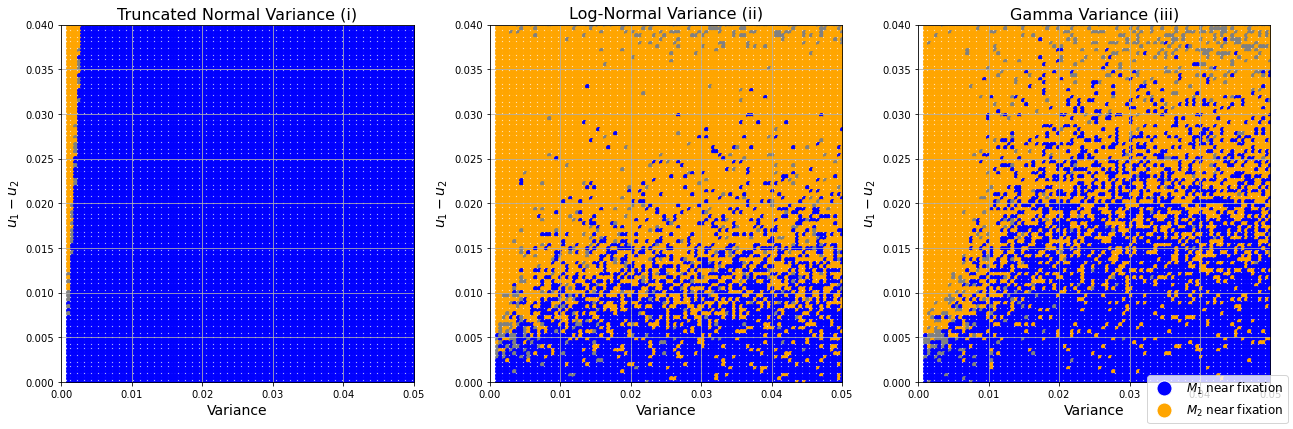

In [87]:
# Parameters
generations = 1000
u1 = 0.05
s = 0.2
R = 0.0
dot_size = 25

# Initial condition with random perturbation
t1, t2 = np.random.uniform(0, 0.01, 2)
total_t = t1 + t2
x1_init = 0.76 - total_t / 2
x2_init = t1
x3_init = 0.24 - total_t / 2 
x4_init = t2

# Grid for plotting
u2_mean_values = np.linspace(0.01, u1, 100)
variance_values = np.linspace(0.001, 0.05, 100)

distributions = ["truncated_normal", "log_normal", "gamma"]
titles = [
    "Truncated Normal Variance (i)",
    "Log-Normal Variance (ii)",
    "Gamma Variance (iii)"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, distribution in enumerate(distributions):
    ax = axes[idx]

    for u2_mean in u2_mean_values:
        for variance in variance_values:
            sigma_u = np.sqrt(variance) if distribution == "truncated_normal" else None

            freqs, actual_variance = simulate_stochastic_mutation(
                sigma_u=sigma_u,
                variance=variance,
                u2_mean=u2_mean,
                initial_frequencies=[x1_init, x2_init, x3_init, x4_init],
                timesteps=generations,
                u1=u1,
                u3=0.01,
                s=s,
                R=R,
                distribution=distribution,
            )

            # Group by modifier allele
            M1_final = freqs[-1, 0] + freqs[-1, 2]  # AM1 + aM1
            M2_final = freqs[-1, 1] + freqs[-1, 3]  # AM2 + aM2

            # Assign color
            if M1_final > 0.95:
                color = "blue"
            elif M2_final > 0.95:
                color = "orange"
            else:
                color = "gray"

            ax.scatter(actual_variance, u1 - u2_mean, color=color, s=15)

    ax.set_xlabel("Variance", fontsize=14)
    ax.set_ylabel(r"$u_1 - u_2$", fontsize=14)
    ax.set_title(titles[idx], fontsize=16)
    ax.grid(True)
    ax.set_xlim(0, 0.05)
    ax.set_ylim(0, 0.04)

# Legend
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markersize=15, markerfacecolor="blue", label=r"$M_1$ near fixation"),
    plt.Line2D([0], [0], marker="o", color="w", markersize=15, markerfacecolor="orange", label=r"$M_2$ near fixation"),
]
fig.legend(handles=handles, loc="lower right", fontsize=12)
plt.tight_layout()
plt.show()
